<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/61ClusteringPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 25: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


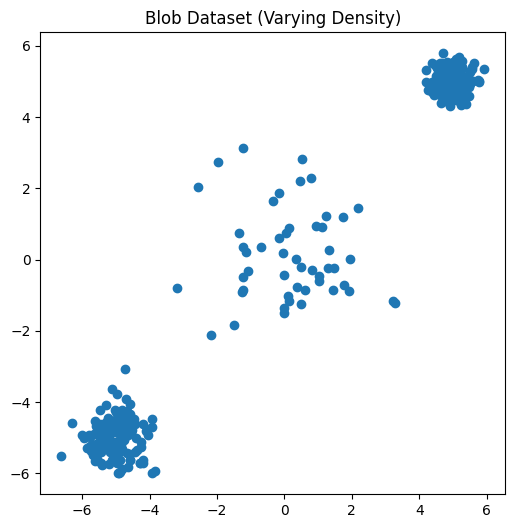

In [1]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import pandas as pd

# Ensure data is generated if kernel was restarted

# print(X_blobs)
# TODO: Scale the dataset and verify that the mean is ~0 and variance is ~1
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_blobs)

print(f'Mean: {X_scaled.mean(axis=0)}')
print(f'Variance: {X_scaled.var(axis=0)}')
# Challenge: Check the summary statistics of the scaled data
df_scaled = pd.DataFrame(X_scaled, columns=['x1', 'x2'])
print(df_scaled.describe())

Mean: [ 7.60502772e-17 -6.77236045e-17]
Variance: [1. 1.]
                 x1            x2
count  4.000000e+02  4.000000e+02
mean   5.773160e-17 -6.439294e-17
std    1.001252e+00  1.001252e+00
min   -1.552926e+00 -1.423594e+00
25%   -1.172044e+00 -1.159617e+00
50%    6.645817e-01  6.608559e-01
75%    9.330801e-01  9.311268e-01
max    1.132521e+00  1.103948e+00



### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


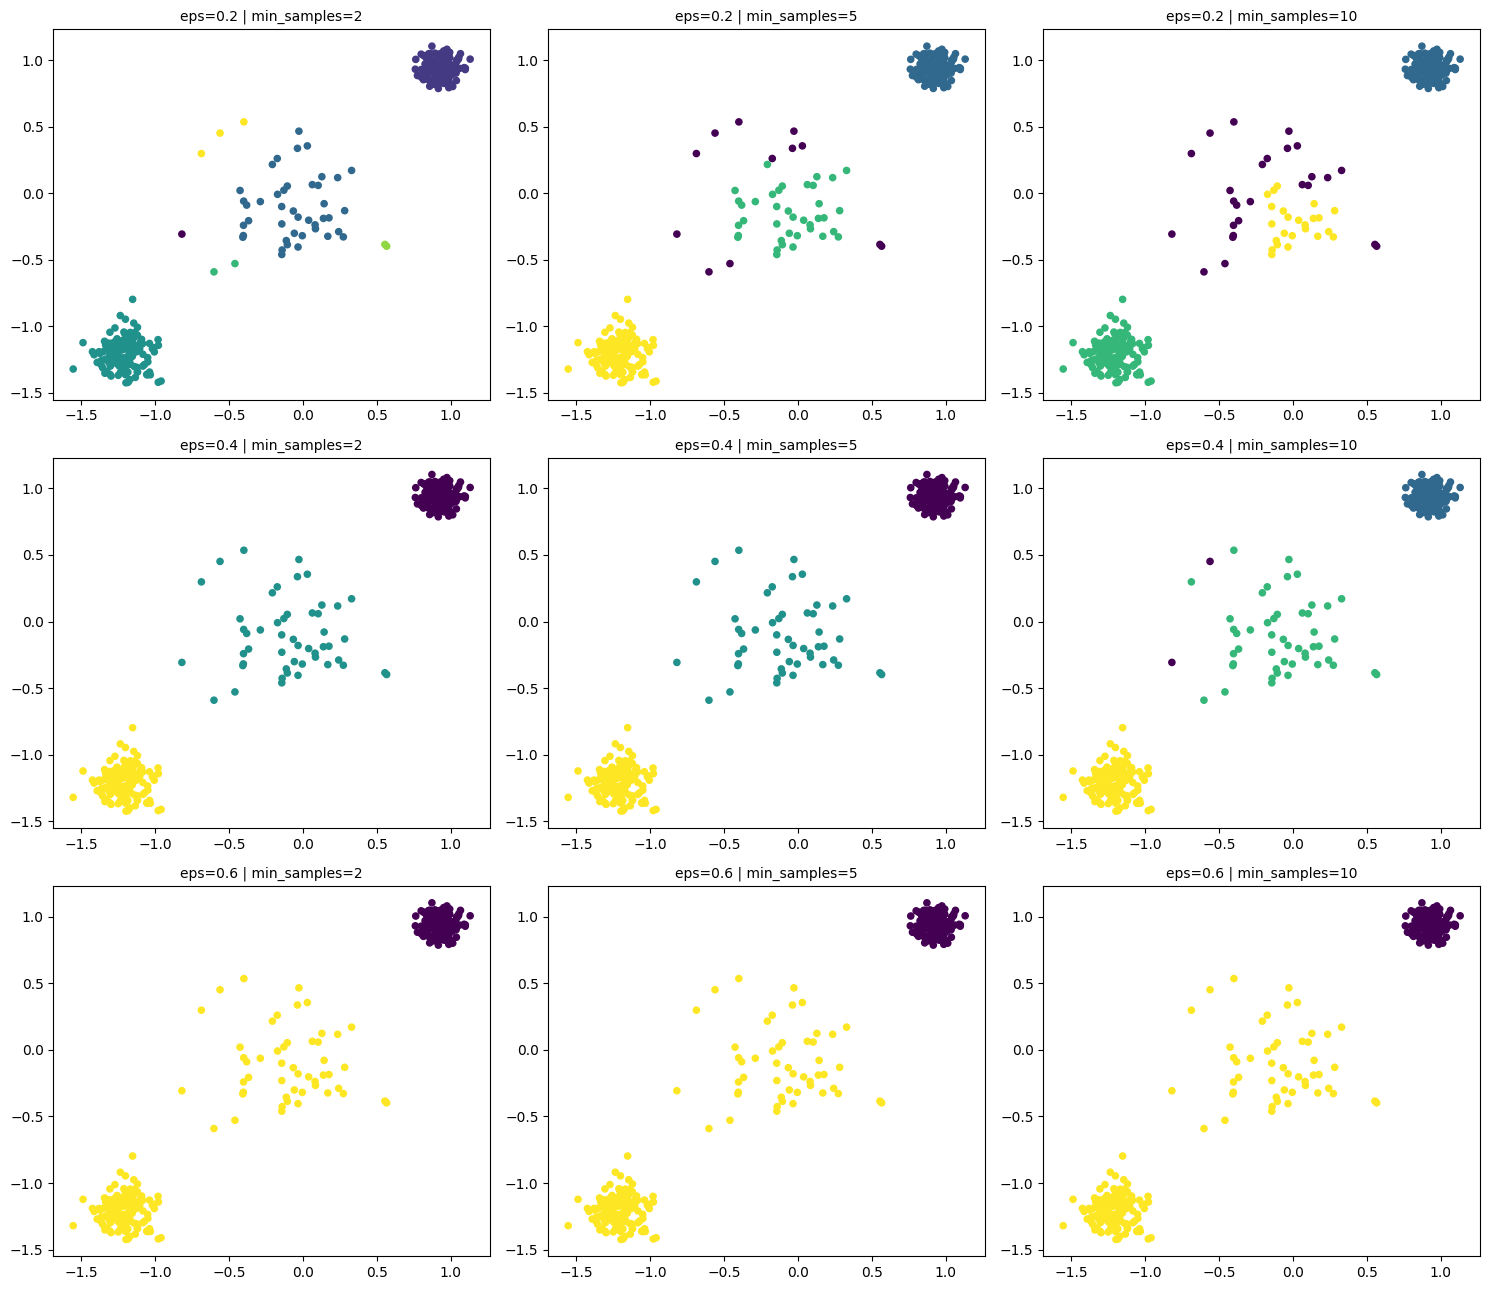

In [6]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# TODO: Implement DBSCAN
# Challenge: Create a function that loops through a grid of eps [0.2, 0.4, 0.6]
# and min_samples [2, 5, 10] and plots the results in a 3x3 subplot grid.
def DBSCAN_grid(X_scaled, eps_values, min_samples_values):
  fig, axes = plt.subplots(3, 3, figsize=(15, 13))

  for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
      db = DBSCAN(eps = eps, min_samples=min_samples)
      db.fit(X_scaled)
      labels = db.labels_

      ax = axes[i, j]
      ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c = labels, cmap='viridis', s = 20)
      ax.set_title(f"eps={eps} | min_samples={min_samples}", fontsize=10)

  plt.tight_layout()
  plt.show()

DBSCAN_grid(X_scaled, [0.2, 0.4, 0.6], [2, 5, 10])


### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


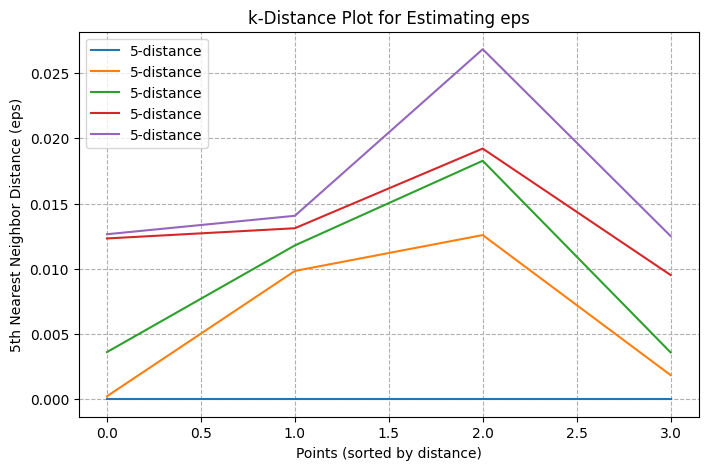

In [11]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# TODO: Create k-distance plot
# Challenge: Use the 'knee' point detection logic.
# Calculate distances to the 5th nearest neighbor, sort them, and plot.
nearest_neighbours = NearestNeighbors(n_neighbors=5)
nearest_neighbours.fit(X_scaled)

distances, indices = nearest_neighbours.kneighbors(X_scaled)
fifth_neighbors_distance = np.sort(distances[: 4])

plt.figure(figsize=(8,5))
plt.plot(fifth_neighbors_distance, label = '5-distance')

plt.title('k-Distance Plot for Estimating eps')
plt.xlabel('Points (sorted by distance)')
plt.ylabel('5th Nearest Neighbor Distance (eps)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


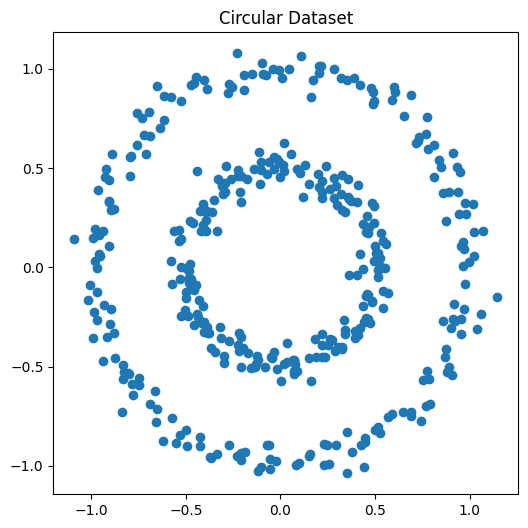

In [12]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()

In [13]:
scaler = StandardScaler()

X_scaled_2 = scaler.fit_transform(X_circles)


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


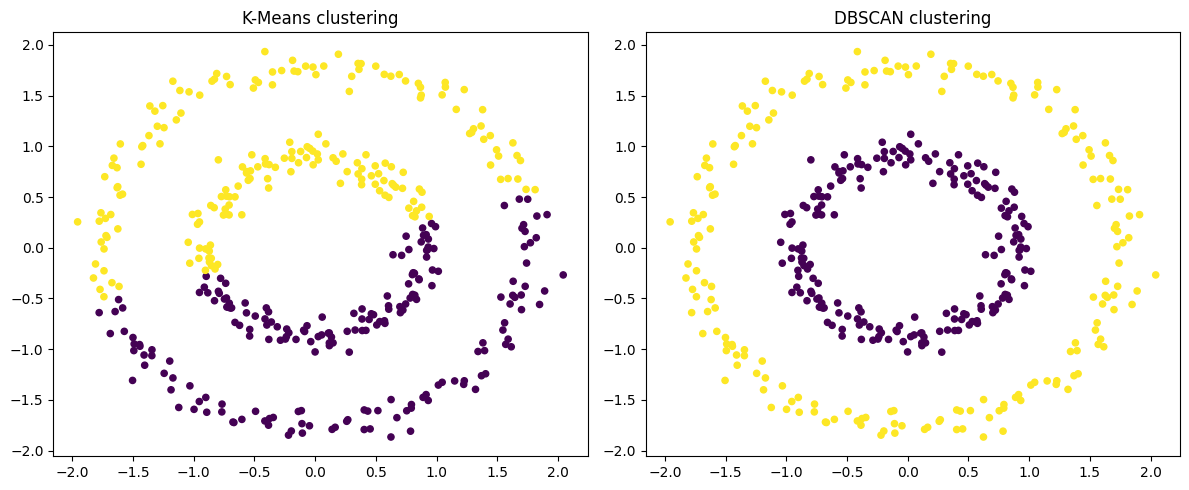

In [17]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Ensure data is generated

# TODO: Compare DBSCAN results side-by-side with K-Means (k=2)

# KMeans (Expect failure for non-convex shapes)

# DBSCAN (Expect success for dense regions)

Kmeans = KMeans(n_clusters=2, random_state = 42)
Kmeans.fit(X_scaled_2)
labels_kmeans = Kmeans.labels_

DBSCAN_clus = DBSCAN(eps = 0.3, min_samples = 5)
DBSCAN_clus.fit(X_scaled_2)
labels_DBSCAN = DBSCAN_clus.labels_

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].scatter(X_scaled_2[:, 0], X_scaled_2[:, 1], c = labels_kmeans, cmap = 'viridis', s = 20)
axes[0].set_title('K-Means clustering')

axes[1].scatter(X_scaled_2[:, 0], X_scaled_2[:, 1], c = labels_DBSCAN, cmap = 'viridis', s = 20)
axes[1].set_title('DBSCAN clustering')

plt.tight_layout()
plt.show()


## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


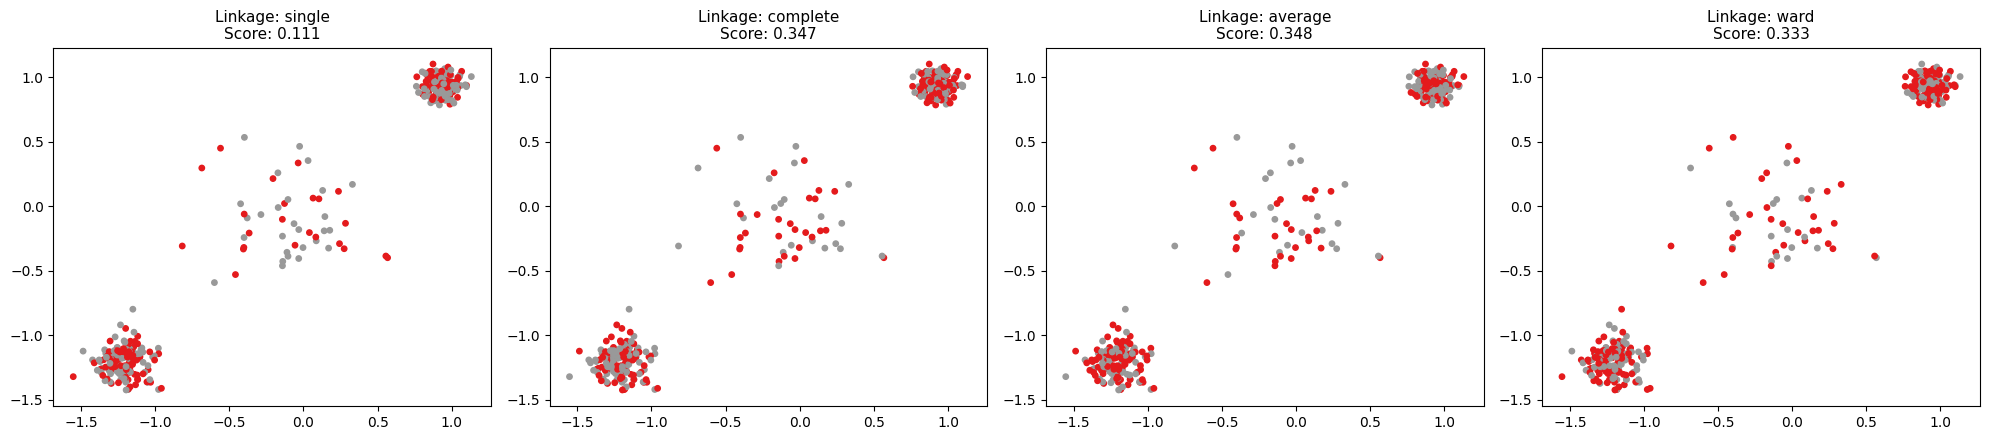

In [18]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering
# Challenge: For each linkage method, calculate the Silhouette Score.

linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, linkage in enumerate(linkage_methods):
  agg = AgglomerativeClustering(n_clusters = 2, linkage = linkage)
  agg.fit(X_scaled_2)
  labels_agg = agg.labels_

  sil_score = silhouette_score(X_scaled_2, labels_agg)

  ax = axes[idx]
  ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg, cmap='Set1', s=15)
  ax.set_title(f"Linkage: {linkage}\nScore: {sil_score:.3f}", fontsize=11)

plt.tight_layout()
plt.show()


### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


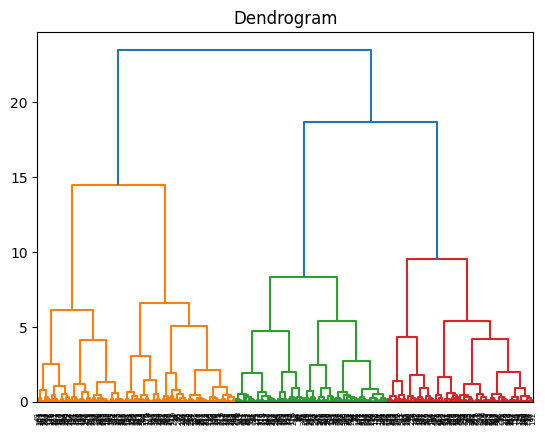

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here

linkage_matrix = linkage(X_scaled_2, method = 'ward')
dendrogram(linkage_matrix)
plt.title('Dendrogram')
plt.show()

## The Grand Challenge: 3D Density Optimization

In this final, hard challenge, we will step into 3D space and automate our parameter selection.

### Requirements:
1. **Generate 3D Data**: Use `make_blobs` to create 1000 samples in 3D space with varying standard deviations.
2. **Parameter Grid Search**: Write a loop that tests `eps` from 0.1 to 1.0 and `min_samples` from 2 to 10.
3. **Optimization**: Find the combination that maximizes the `silhouette_score` (excluding noise points).
4. **3D Visualization**: Plot the final optimized clusters using a 3D scatter plot.

🥇 Optimization Success!
Best eps: 0.10
Best min_samples: 10
Maximized Silhouette Score (Excluding Noise): 0.8982


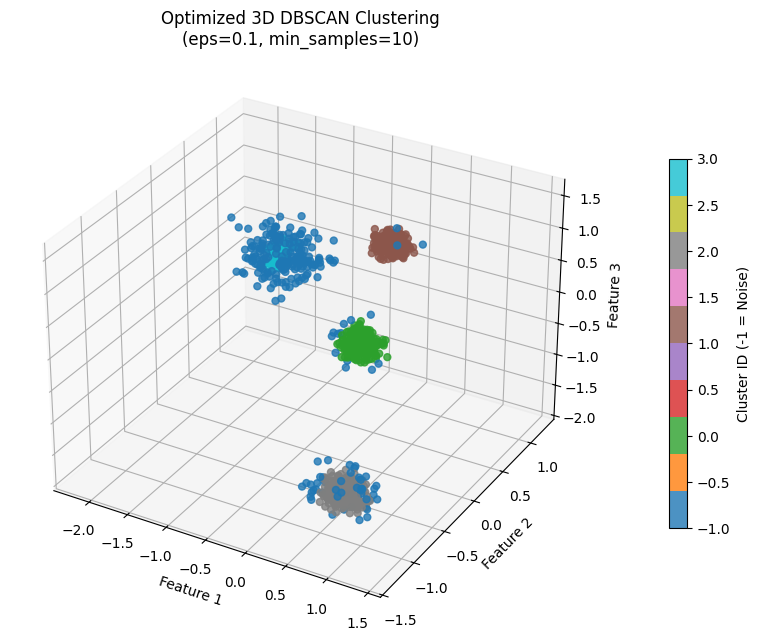

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 1. Generate 3D Data
X, y = make_blobs(
    n_samples=1000,
    n_features=3,
    centers=4,
    cluster_std=[0.5, 0.8, 1.2, 0.6],
    random_state=42
)
X_scaled = StandardScaler().fit_transform(X)

# 2. Parameter Grid Search & 3. Optimization
eps_range = np.linspace(0.1, 1.0, 10)  # [0.1, 0.2, ..., 1.0]
min_samples_range = list(range(2, 11))  # [2, 3, ..., 10]

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

for eps in eps_range:
    for min_samples in min_samples_range:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        # print(labels)
        # Filter out noise points (-1) for core cluster evaluation
        non_noise_mask = labels != -1
        core_labels = labels[non_noise_mask]
        core_X = X_scaled[non_noise_mask]

        # Silhouette score requires at least 2 distinct clusters to be calculated
        unique_core_clusters = len(np.unique(core_labels))
        if unique_core_clusters >= 2:
            score = silhouette_score(core_X, core_labels)

            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

print(f"🥇 Optimization Success!")
print(f"Best eps: {best_eps:.2f}")
print(f"Best min_samples: {best_min_samples}")
print(f"Maximized Silhouette Score (Excluding Noise): {best_score:.4f}")

# 4. 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Highlight noise points distinctively if they exist
scatter = ax.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 2],
    c=best_labels,
    cmap='tab10',
    s=25,
    alpha=0.8
)

ax.set_title(f"Optimized 3D DBSCAN Clustering\n(eps={best_eps:.1f}, min_samples={best_min_samples})", fontsize=12)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

# Add a colorbar legend for clusters
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
colorbar.set_label("Cluster ID (-1 = Noise)")

plt.show()